In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import scienceplots as _  # noqa: F401
from atab10 import atab10

plt.style.use(["science", "nature"])

GOLDEN_RATIO = (1 + 5**0.5) / 2
SILVER_RATIO = 1 + 2**0.5


LABELS = {
    "dd.f1": "F1 Score",
    "dd.wasserstein_distance": "Wasserstein Distance",
}

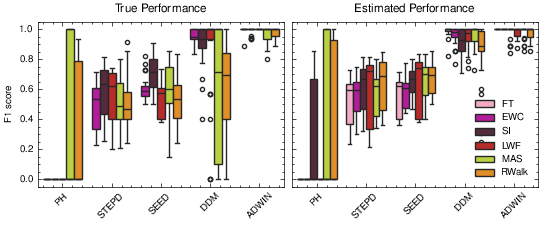

In [2]:
df_evaluate = pd.read_csv("../logs/evaluate/data_frame.csv")
df_dd_run = pd.read_csv("../logs/dd_run/data_frame.csv")

width = 390
# silver ratio
aspect = 1 + 2**0.5
scale = 1 / 72
figsize = (width * scale, (width * scale) / aspect)

cmap = {
    "FT": atab10(0),
    "EWC": atab10(1),
    "SI": atab10(2),
    "LWF": atab10(3),
    "RWalk": atab10(4),
    "MAS": atab10(5),
}

metric = "dd.f1"


def filters(df: pd.DataFrame) -> pd.DataFrame:
    mask = ~df.detector_label.isin(["oracle", "ADWIN_JOINT"])
    return df[mask]


df_evaluate = filters(df_evaluate)
df_dd_run = filters(df_dd_run)

fig, (ax_true, ax_sim) = plt.subplots(
    1, 2, figsize=figsize, sharey=True, constrained_layout=True
)
axies = [ax_true, ax_sim]

order = df_evaluate.groupby("detector_label")[metric].median().sort_values().index

sns.boxplot(
    data=df_evaluate,
    hue="strategy",
    y=metric,
    x="detector_label",
    ax=ax_true,
    palette=cmap,
    legend=False,
    order=order,
)
ax_true.set_title("True Performance")
ax_true.set_xlabel("")

sns.boxplot(
    data=df_dd_run,
    hue="strategy",
    y=metric,
    x="detector_label",
    ax=ax_sim,
    palette=cmap,
    legend=True,
    order=order,
)

# Remove legend title
handles, labels = ax_sim.get_legend_handles_labels()
ax_sim.legend(handles=handles, labels=labels, title="", loc="lower right")

ax_sim.set_title("Estimated Performance")
ax_sim.set_xlabel("")

for ax in axies:
    ax.tick_params(axis="x", rotation=45)
    # ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.set_ylabel("F1 score")

fig.savefig("../fig/detector_performance.pdf")

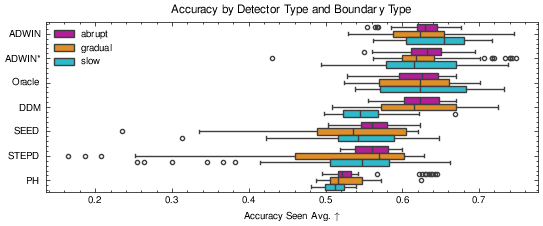

In [3]:
df_true = pd.read_csv("../logs/evaluate/data_frame.csv")
df_true["detector_label"] = df_true["detector_label"].replace(
    {"ADWIN_JOINT": "ADWIN*", "oracle": "Oracle"}
)
width = 390
aspect = SILVER_RATIO
scale = 1 / 72
figsize = (width * scale, (width * scale) / aspect)


order = (
    df_true.groupby("detector_label")["ocl.accuracy_seen_avg"]
    .mean()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
sns.boxplot(
    data=df_true,
    hue="boundary",
    x="ocl.accuracy_seen_avg",
    y="detector_label",
    legend=True,
    palette=atab10.colors[1::3],
    order=order,
    ax=ax,
)
ax.set_xlabel(r"Accuracy Seen Avg. $\uparrow$")
ax.legend_.set_title(None)
ax.set_ylabel(None)
ax.set_title("Accuracy by Detector Type and Boundary Type")
fig.savefig("../fig/acc_boundary_detector.pdf")